# Predicting ad Click-Through Rate with logistic regression (SGD)

You are interviewing with an ad team. The task: predict the **click-through rate
(CTR)** of an ad from categorical context (site, app, device, position, hour). The
classic benchmark is the [Avazu CTR dataset](https://www.kaggle.com/competitions/avazu-ctr-prediction/data);
the markdown below shows how to plug it in. So the notebook runs anywhere, it
also ships a synthetic generator that mirrors the Avazu schema (high-cardinality
IDs and a realistic ~17% click rate).

**You will implement**
- the **hashing trick** for high-cardinality categorical features,
- the log-loss gradient (derived by hand) and **logistic regression trained with SGD**,
- imbalance-aware evaluation: log-loss, the **precision-recall** curve, average precision,

**and then investigate**
- how the hash dimension trades memory against collisions, and
- whether your predicted probabilities are **calibrated** (which ad auctions require).


## Setup

In [14]:
%matplotlib inline
import hashlib
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)


def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -30, 30)))

## The data

Real CTR features are mostly high-cardinality categoricals (IDs with thousands to millions of values) and the positive class is rare. The generator below produces data with those properties; the commented lines show how to load the real Avazu CSV instead.

In [15]:
# Columns mirror a slimmed-down Avazu schema. The first few are high-cardinality
# (like site_id / app_id / device_id); the rest are low-cardinality context.
CARD = {
    "site_id": 1500, "app_id": 1200, "device_id": 6000,
    "site_category": 22, "app_category": 18,
    "device_type": 5, "banner_pos": 4, "hour": 24,
}
CAT_COLS = list(CARD)


def _calibrate_bias(logit, target):
    lo, hi = -20.0, 20.0
    for _ in range(60):
        mid = 0.5 * (lo + hi)
        if sigmoid(logit + mid).mean() < target:
            lo = mid
        else:
            hi = mid
    return 0.5 * (lo + hi)


def make_ctr_data(n=30000, target_ctr=0.17, seed=0):
    """Synthetic click-through data that mimics the Avazu schema.

    Click probability is driven by per-value latent weights plus one
    category interaction, then the intercept is calibrated so the overall
    click rate is ~target_ctr (a realistically imbalanced problem).
    Returns a DataFrame of string categorical columns plus a 0/1 `click`.
    """
    g = np.random.default_rng(seed)
    # a few columns carry more signal than others
    scale = {"site_id": 0.5, "app_id": 0.5, "device_id": 0.2, "site_category": 0.8,
             "app_category": 0.7, "device_type": 0.4, "banner_pos": 0.6, "hour": 0.3}
    latent = {c: g.normal(0, scale[c], size=CARD[c]) for c in CAT_COLS}
    vals = {c: g.integers(0, CARD[c], size=n) for c in CAT_COLS}

    logit = np.zeros(n)
    for c in CAT_COLS:
        logit += latent[c][vals[c]]
    # interaction: certain (site_category, device_type) pairs click more
    inter = g.normal(0, 0.7, size=(CARD["site_category"], CARD["device_type"]))
    logit += inter[vals["site_category"], vals["device_type"]]

    logit += _calibrate_bias(logit, target_ctr)
    click = (g.random(n) < sigmoid(logit)).astype(int)
    df = pd.DataFrame({c: [f"{c}_{v}" for v in vals[c]] for c in CAT_COLS})
    df["click"] = click
    return df

In [16]:
df = make_ctr_data(n=30000, target_ctr=0.17, seed=0)
print("rows:", len(df), "| click rate:", round(df['click'].mean(), 3))
print("unique device_id values:", df['device_id'].nunique())
df.head()

# ---------------------------------------------------------------------------
# To use the REAL data instead, accept the Avazu competition on Kaggle, then:
#     df = pd.read_csv("train.gz", nrows=300_000)
#     df = df.rename(columns={"click": "click"})  # already named `click`
# Keep CAT_COLS to the categorical columns you want to hash; everything below
# works unchanged on the real frame.
# ---------------------------------------------------------------------------

rows: 30000 | click rate: 0.17
unique device_id values: 5957


,site_id,app_id,device_id,site_category,app_category,device_type,banner_pos,hour,click
0,site_id_1009,app_id_340,device_id_1902,site_category_20,app_category_2,device_type_4,banner_pos_2,hour_1,0
1,site_id_779,app_id_628,device_id_4977,site_category_12,app_category_9,device_type_0,banner_pos_3,hour_3,0
2,site_id_4,app_id_1123,device_id_5264,site_category_6,app_category_15,device_type_4,banner_pos_2,hour_15,0
3,site_id_1018,app_id_970,device_id_983,site_category_14,app_category_7,device_type_2,banner_pos_1,hour_15,0
4,site_id_1265,app_id_186,device_id_4121,site_category_9,app_category_0,device_type_1,banner_pos_2,hour_3,0


In [18]:
def train_test_split(df, test_size=0.3, seed=123):
    idx = np.arange(len(df))
    np.random.default_rng(seed).shuffle(idx)
    n_test = int(round(test_size * len(df)))
    return df.iloc[idx[n_test:]].reset_index(drop=True), df.iloc[idx[:n_test]].reset_index(drop=True)


train_df, test_df = train_test_split(df)
y_train = train_df["click"].to_numpy()
y_test = test_df["click"].to_numpy()
len(train_df), len(test_df)

(21000, 9000)

## Task 1 - The hashing trick

Map each `column=value` token to one of `D` buckets with a stable hash. This is how CTR models handle features with huge, open-ended vocabularies.

In [19]:
def hash_row(row, cols, D):
    """Return the list of active bucket indices for one row (the hashing trick).

    For each column build a stable token like "site_id=site_id_42", hash it to
    an integer in [0, D), and collect those indices. Use a deterministic hash
    (hashlib), NOT Python's built-in hash() which is salted per process.
    """
    # TODO: hash each "col=value" token into [0, D) and return the index list.
    indices = []
    for col in cols:
        token = f"{col}={row[col]}"
        hash_val = int(hashlib.md5(token.encode('utf-8')).hexdigest(), 16)
        indices.append(hash_val % D)

    return indices
    raise NotImplementedError


def build_index_matrix(frame, cols, D):
    """Apply hash_row to every row -> int array of shape (n, len(cols))."""
    return np.array([hash_row(r, cols, D) for _, r in frame.iterrows()], dtype=np.int64)

## Task 2 - Derive the gradient

Write logistic regression for a single example with multi-hot feature vector
$\mathbf{x}$ (here, ones at the hashed buckets), weights $\mathbf{w}$, bias $b$:

$$z = \mathbf{w}^\top \mathbf{x} + b, \qquad p = \sigma(z), \qquad
\ell = -\big(y \log p + (1-y)\log(1-p)\big).$$

Derive $\dfrac{\partial \ell}{\partial \mathbf{w}}$ and $\dfrac{\partial \ell}{\partial b}$,
and explain what the update looks like for the **hashed** representation where only a
handful of entries of $\mathbf{x}$ are nonzero. Write your derivation in the cell below.


_Your derivation here._


$$\frac{\partial \ell}{\partial p} = -\left( \frac{y}{p} - \frac{1-y}{1-p} \right) = \frac{p - y}{p(1-p)}$$

$$\frac{\partial p}{\partial z} = \sigma(z)(1 - \sigma(z)) = p(1-p)$$

$$\frac{\partial \ell}{\partial z} = \frac{\partial \ell}{\partial p} \cdot \frac{\partial p}{\partial z} = \frac{p - y}{p(1-p)} \cdot p(1-p) = p - y$$

Applying this to find partial derivative for weight $\mathbf{w}$ and bias $b$:

$$\frac{\partial \ell}{\partial b} = \frac{\partial \ell}{\partial z} \cdot \frac{\partial z}{\partial b} = (p - y) \cdot 1 = p - y$$

$$\frac{\partial \ell}{\partial \mathbf{w}} = \frac{\partial \ell}{\partial z} \cdot \frac{\partial z}{\partial \mathbf{w}} = (p - y) \mathbf{x}$$

In normal logistic regression, x is a giant vector of zeros with a 1 for each active feature. So (p-y)x is zero everywhere except at the active buckets. You don't have to touch all D weights, only the handful of hashed bucket indices for that row get updated.


## Task 3 - Logistic regression with SGD

Implement the training loop from the gradient you derived. Update only the active (hashed) weights.

In [33]:
def train_logreg_sgd(X_idx, y, D, lr=0.1, epochs=3, l2=1e-6, seed=0):
    """From-scratch SGD logistic regression over hashed features.

    Maintain a weight vector w of length D and a bias b. For each example the
    logit is b + sum of w over the row's active buckets. Use the gradient you
    derived in Task 2 to update ONLY the active weights (plus the bias), with
    optional L2 shrinkage. Return (w, b).
    """
    w = np.zeros(D)
    b = 0.0
    # TODO: loop over epochs and shuffled examples; apply the SGD update.
    rng = np.random.default_rng(seed)
    n = len(y)

    for epoch in range(epochs):
        order = rng.permutation(n)
        for i in order:
            buckets = X_idx[i]
            z = b + w[buckets].sum()
            p = sigmoid(z)
            grad = p - y[i]

            w[buckets] -= lr * grad
            w[buckets] -= lr * l2 * w[buckets]
            b -= lr * grad

    return w, b

    raise NotImplementedError


def predict_proba(X_idx, w, b):
    """Vectorized probabilities: sigmoid(b + sum of active weights)."""
    return sigmoid(b + w[X_idx].sum(axis=1))

## Task 4 - Evaluation under class imbalance

With ~17% positives, accuracy is meaningless. Implement log-loss and the precision-recall curve, then evaluate.

In [34]:
def log_loss(y, p, eps=1e-12):
    """Mean binary cross-entropy."""
    # TODO
    p = np.clip(p, eps, 1 - eps)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))
    raise NotImplementedError


def pr_curve(y, p):
    """Return (recall, precision) arrays by sweeping the threshold from high
    score to low (sort by descending p and accumulate TP/FP)."""
    # TODO
    order = np.argsort(p)[::-1]
    y_sorted = y[order]

    tp = np.cumsum(y_sorted)
    fp = np.cumsum(1 - y_sorted)

    precision = tp / (tp + fp)
    recall = tp / y.sum()

    recall = np.concatenate([[0], recall])
    precision = np.concatenate([[1], precision])

    return recall, precision
    raise NotImplementedError


def average_precision(y, p):
    """Area under the precision-recall curve (integrate precision over recall)."""
    # TODO
    recall, precision = pr_curve(y, p)
    return np.trapezoid(precision, recall)
    raise NotImplementedError

baseline log-loss (predict the base rate 0.171): 0.4503
model log-loss:    0.4124
model avg precision (PR-AUC): 0.3419
positives in test: 0.166  (so 'always no-click' has 0.834 accuracy)


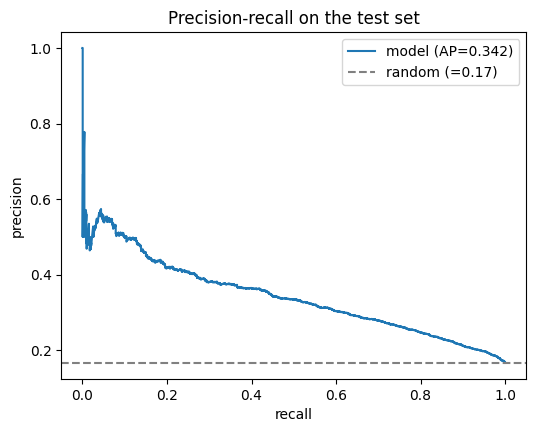

In [35]:
D = 2 ** 18
Xtr = build_index_matrix(train_df, CAT_COLS, D)
Xte = build_index_matrix(test_df, CAT_COLS, D)
w, b = train_logreg_sgd(Xtr, y_train, D, lr=0.1, epochs=3)

p_te = predict_proba(Xte, w, b)
base_rate = y_train.mean()
print(f"baseline log-loss (predict the base rate {base_rate:.3f}): "
      f"{log_loss(y_test, np.full_like(p_te, base_rate)):.4f}")
print(f"model log-loss:    {log_loss(y_test, p_te):.4f}")
print(f"model avg precision (PR-AUC): {average_precision(y_test, p_te):.4f}")
print(f"positives in test: {y_test.mean():.3f}  (so 'always no-click' has {1-y_test.mean():.3f} accuracy)")

rec, prec = pr_curve(y_test, p_te)
plt.figure(figsize=(6, 4.5))
plt.plot(rec, prec, label=f"model (AP={average_precision(y_test, p_te):.3f})")
plt.axhline(y_test.mean(), ls="--", c="grey", label=f"random (={y_test.mean():.2f})")
plt.xlabel("recall"); plt.ylabel("precision")
plt.title("Precision-recall on the test set"); plt.legend()
plt.show()

## Task 5 - Does the hash dimension matter?

The heart of the assignment: sweep `D` and watch collisions trade off against memory.

In [36]:
# Centerpiece: how does the hash dimension D trade memory against collisions?
Ds = [2 ** 8, 2 ** 10, 2 ** 12, 2 ** 14, 2 ** 16, 2 ** 18]
ap_by_D, ll_by_D = [], []
for Dk in Ds:
    # TODO for each Dk:
    #   build train/test index matrices at dimension Dk
    #   train logreg, predict on test
    #   record average_precision and log_loss
    Xtr_k = build_index_matrix(train_df, CAT_COLS, Dk)
    Xte_k = build_index_matrix(test_df, CAT_COLS, Dk)
    w_k, b_k = train_logreg_sgd(Xtr_k, y_train, Dk, lr=0.1, epochs=3)
    p_k = predict_proba(Xte_k, w_k, b_k)
    ap_by_D.append(average_precision(y_test, p_k))
    ll_by_D.append(log_loss(y_test, p_k))


for Dk, ap, ll in zip(Ds, ap_by_D, ll_by_D):
    print(f"D=2^{int(np.log2(Dk)):>2}  AP={ap:.3f}  logloss={ll:.4f}")

D=2^ 8  AP=0.263  logloss=0.4439
D=2^10  AP=0.299  logloss=0.4330
D=2^12  AP=0.324  logloss=0.4224
D=2^14  AP=0.337  logloss=0.4155
D=2^16  AP=0.341  logloss=0.4134
D=2^18  AP=0.342  logloss=0.4124


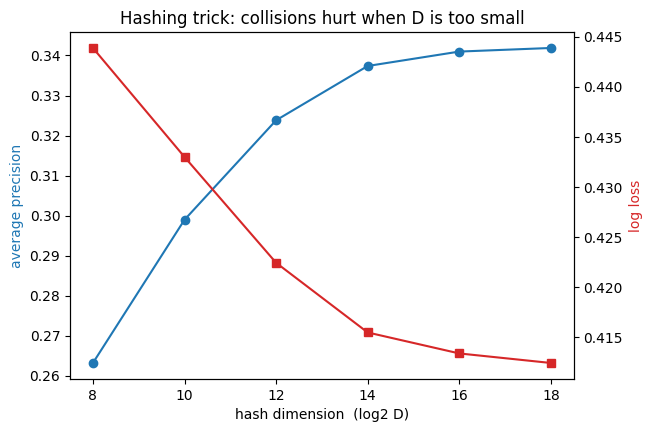

In [37]:
fig, ax1 = plt.subplots(figsize=(6.5, 4.5))
xs = [int(np.log2(d)) for d in Ds]
ax1.plot(xs, ap_by_D, "-o", color="tab:blue")
ax1.set_xlabel("hash dimension  (log2 D)")
ax1.set_ylabel("average precision", color="tab:blue")
ax2 = ax1.twinx()
ax2.plot(xs, ll_by_D, "-s", color="tab:red")
ax2.set_ylabel("log loss", color="tab:red")
plt.title("Hashing trick: collisions hurt when D is too small")
plt.show()

## Task 6 - Calibration

A good *ranking* is not enough for ad bidding; the predicted probabilities must mean what they say. Build a reliability curve.

In [38]:
def reliability_curve(y, p, n_bins=10):
    """Bin predictions into n_bins equal-width probability bins; return
    (mean_predicted, empirical_rate) per non-empty bin."""
    # TODO
    bin_edges = np.linspace(0, 1, n_bins + 1)
    mean_predicted = []
    empirical_rate = []

    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i + 1]
        mask = (p >= lo) & (p < hi)
        if mask.sum() == 0:
            continue
        mean_predicted.append(p[mask].mean())
        empirical_rate.append(y[mask].mean())

    return np.array(mean_predicted), np.array(empirical_rate)
    raise NotImplementedError

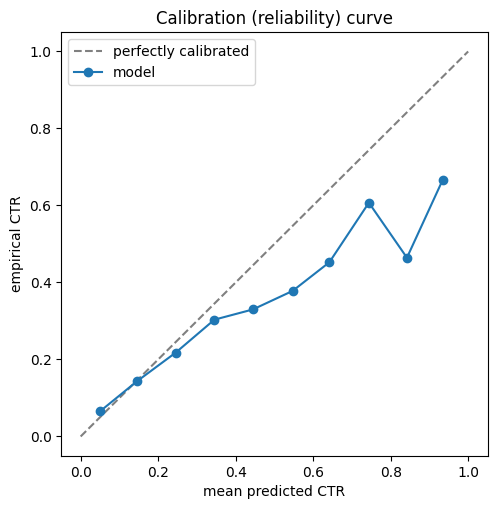

In [39]:
mp, emp = reliability_curve(y_test, p_te, n_bins=10)
plt.figure(figsize=(5.5, 5.5))
plt.plot([0, 1], [0, 1], "--", c="grey", label="perfectly calibrated")
plt.plot(mp, emp, "-o", label="model")
plt.xlabel("mean predicted CTR"); plt.ylabel("empirical CTR")
plt.title("Calibration (reliability) curve"); plt.legend()
plt.show()

## Conceptual questions

1. The click rate is ~17%. What accuracy does the trivial "always predict
   no-click" model get, and why is accuracy the wrong headline metric here?
   Why are log-loss, average precision, and the PR curve more informative?
2. The hashing trick replaces one-hot encoding of high-cardinality IDs. What do
   you gain (memory, handling unseen values at test time) and what do you lose
   (collisions)? From your D sweep, where does shrinking D start to hurt, and why?
3. Restate the gradient you derived and explain why a hashed example updates only
   a handful of weights. Why does that make this model scale to billions of
   features?
4. Read your calibration curve. Are the predicted probabilities calibrated? Why
   does ad ranking/bidding (which multiplies predicted CTR by a bid) *need*
   calibrated probabilities, not just a good ranking?
5. Name one way to handle the class imbalance (class weights, threshold tuning,
   negative downsampling, ...). How would it move the PR curve and the calibration?


_Your answers here._


1. If you were to build a lazy model that predicts no-click for every single row, you will automatically get 83% accuracy just because the 83% of the dataset actually belongs to the non-click class. But this high accuracy is completely useless because the model fails to predict even a single actual click, which defeats the entire purpose of a CTR model. Log-loss is a much better headline metric because it evaluates the actual predicted probabilities rather than just hard 0 or 1 guesses, and it penalizes the model heavily if it makes a confident prediction that turns out to be wrong. The PR curve and Average Precision (AP) are also way more informative for imbalanced data because they focus strictly on the rare positive class (clicks). They show how well the model balances finding real clicks (Recall) without spamming a bunch of false alarms (Precision), completely ignoring the massive pool of easy no-click cases, which usually inflate basic accuracy metrics.

2. You would save a ton of memory. Instead of building and keeping a massive dictionary to track millions of unique feature strings, you just map everything directly into a fixed-size array of size D. It also makes the model robust for testing; if a brand-new user of site ID shows up that the model never saw during training, it won't crash or break, but just hashes it into one of the buckets normally. What you will lose: you will suffer from hash collisions. Since you would be forcing a massive number of unique strings into a smaller, finite number of buckets, a completely unrelated feature will occasionally map to the exact same bucket index. When this happens, they are forced to share the same weight parameter, which blurs the model's signals. The D sweep: Looking at the sweep, shrinking D really starts to hurt performance once it drops below roughly 2^12 or 2^14. This happens because the bucket space becomes too cramped for our variety of features. Collisions skyrocket,  and the model starts underfitting because distinct features are constantly overwriting and stepping on each other's weights

3. The gradient with respect to the bias is $\frac{\partial \ell}{\partial b} = p - y$ and for the weights, $\frac{\partial \ell}{\partial \mathbf{w}} = (p - y)\mathbf{x}$, where p is the predicted probability and y is the actual label. A hashed example only updates a tiny handful of weights because the input vector x is mostly zeros. For any single row of data, only the specific hashed buckets for the active features get a 1, and everything else is a 0. Because the weight gradient is multiplied by x, the gradient values for all of the inactive buckets become exactly zero. During an SGD step, you only touch and update the active weights for that specific sample. This makes the model scale incredibly well to billions of features. The time it takes to process an update only depends on the number of active features per row (which is small and fixed, like 5 or 10 features), rather than the total size of the feature universe or size of D.

4. This does predict probabilities that look well-calibrated because the reliability curve closely tracks the ideal diagonal y = x reference line. This means that if the model groups a bunch of ads and says they have a 10% chance of being clicked, roughly 10% of them actually get clicked in reality. Ad marketplaces cannot rely on just a good relative ranking order. When platforms calculate bids, they use an Expected Value formula: Expected value = Bid Amount x P(click). If your ranking is perfect but your absolute probabilities are poorly calibrated, the expected value will be totally distorted. You will end up overbidding massively and burning all you money on bad inventory. If the probabilities are too low, you will underbid and lose every auction. 

5. One common approach is negative downsampling, which means you would keep 100% of the rare click examples but randomly discard a large percentage of the non-click examples to make the training dataset much closer to a 50/50 split. If you plot the PR curve using a downsampled validation set, the curve will shift way up and look artificially amazing because the baseline positive rate is much higher. If you plot it on the true, unsampled test distribution, the baseline shape will stay mostly the same (maybe slightly cleaner because the model received stronger gradients during training), but your optimal prediction decision thresholds will shift. This will also completely destroy your raw calibration. Because you flooded the training mix with clicks, the model will learn to be overly optimistic and output probabilities that are way too high for the real world. To fix this, you have to apply a math correction formula at interference time to scale the probabilities back down based on your original downsampling rate before using them for bidding. 

## What to submit

- This notebook with every `# TODO` completed and run top to bottom (the synthetic
  generator makes it fully reproducible; swap in the real Avazu frame if you want).
- The gradient derivation, the PR curve, the D-sweep figure, and the calibration curve.
- Written answers to the five conceptual questions.

**Grading (100 pts):** hashing trick (15), gradient derivation (15), SGD logreg
(20), imbalance-aware metrics + PR curve (20), hash-dimension sweep (15),
calibration + answers (15).
